# TP DSP - Grupo 5: Filtrado e Identificación de Sistemas

## Introducción

Un analizador de doble canal analiza simultáneamente la entrada y salida de un sistema 
para caracterizarlo en frecuencia. La respuesta en frecuencia H(ω) se obtiene como:

$$H(\omega) = \frac{Y(\omega)}{X(\omega)}$$

donde Y(ω) y X(ω) son las transformadas de Fourier de la salida y entrada respectivamente.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funciones import *
import timeit


%matplotlib inline

## Parte 1: Herramientas de análisis

### 1. Generación y gráfico de señales

A continuación se presentan las herramientas destinadas a la generación de señales y su representación visual, mediante ejemplos.

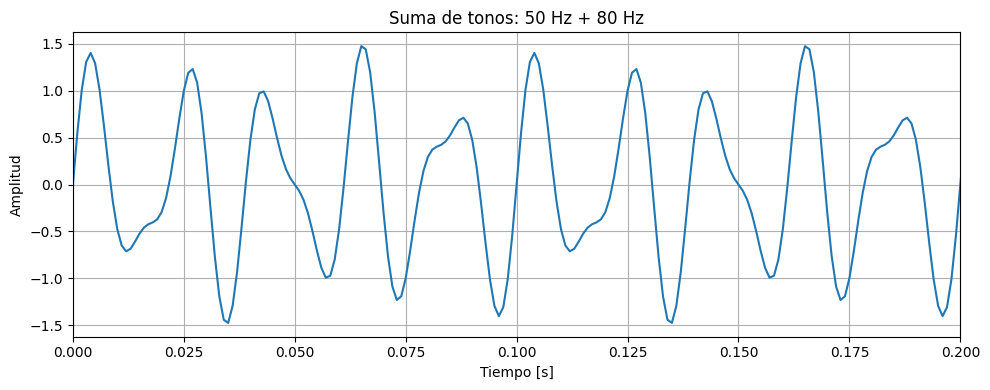

In [2]:
# Parámetros
fs = 1000       # frecuencia de muestreo: 1000 Hz
duracion = 1    # 1 segundo

# Generamos una suma de tonos puros: 50 Hz y 200 Hz
senal = generar_suma_tonos(
    frecuencias=[50, 80],
    amplitudes=[1, 0.5],
    fs=fs,
    duracion=duracion
)

# Graficamos la señal temporal
graficar_senales(senal, fs=fs, titulo="Suma de tonos: 50 Hz + 80 Hz", xlim=(0, 0.2))

A continuación se grafica el espectro de dicha señal mediante una función que utiliza la herramienta de la DFT optimizada mediante el algoritmo de la FFT. Se descarta la mitad del espectro graficado, pues aquí es donde se ubica el aliasing visual producto de las bases de la transformada.

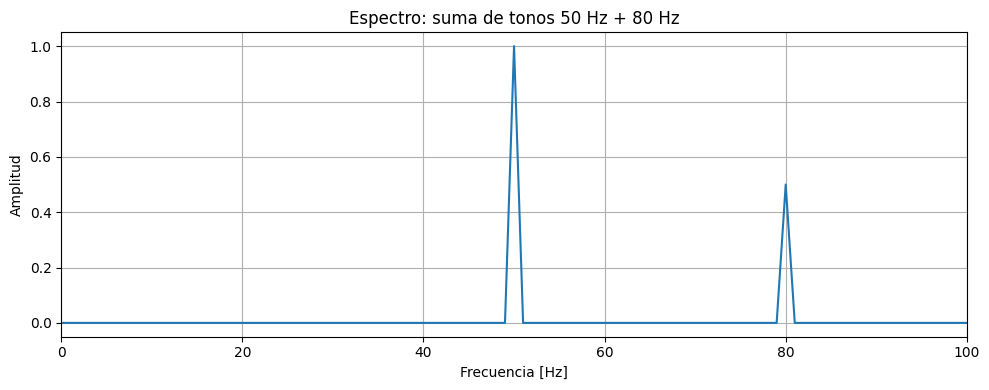

In [3]:
# Graficamos el espectro de la misma señal
graficar_espectros(senal, fs=fs, titulo="Espectro: suma de tonos 50 Hz + 80 Hz", xlim=(0, 100))

Los dos picos en el espectro corresponden exactamente a las frecuencias de los tonos 
generados (50 Hz y 80 Hz), con amplitudes proporcionales a las indicadas (1 y 0.5 
respectivamente).

### 2. Señales con ruido blanco
#### Suma de tonos puros

Aquí se añade ruido a la señal generada:

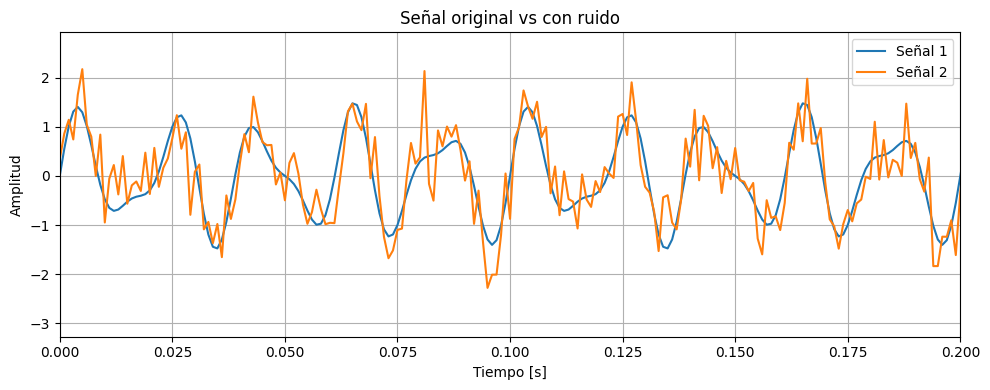

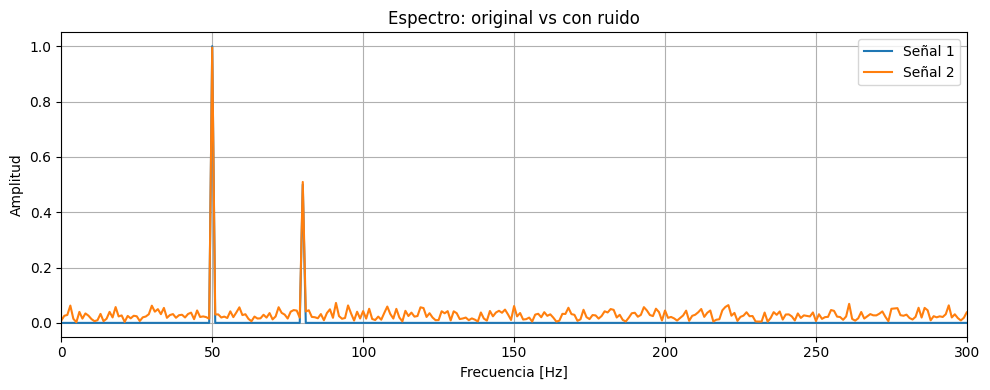

In [4]:
tonos_con_ruido = agregar_ruido_blanco(senal, amplitud=0.5)

graficar_senales([senal, tonos_con_ruido], fs=fs, titulo="Señal original vs con ruido", xlim=(0, 0.2))

graficar_espectros([senal, tonos_con_ruido], fs=fs, titulo="Espectro: original vs con ruido", xlim=(0, 300))

### Observación

Al agregar ruido blanco, en el dominio temporal la señal se ve "sucia" pero todavía 
se reconoce la forma original. En el espectro, el efecto es más revelador: el ruido 
blanco distribuye energía en **todas las frecuencias** de manera uniforme, lo que se 
manifiesta como un "piso" de perturbaciones a lo largo de todo el espectro, en lugar 
de los dos picos limpios de la señal original.

Esto ilustra una propiedad fundamental del ruido blanco: su densidad espectral de 
potencia es constante en todas las frecuencias.

#### Señal musical

Añadiendo ruido a la señal generada:

### 3. Filtros y respuesta al impulso

Se analizan los tres filtros requeridos: media móvil, peine y FIR.

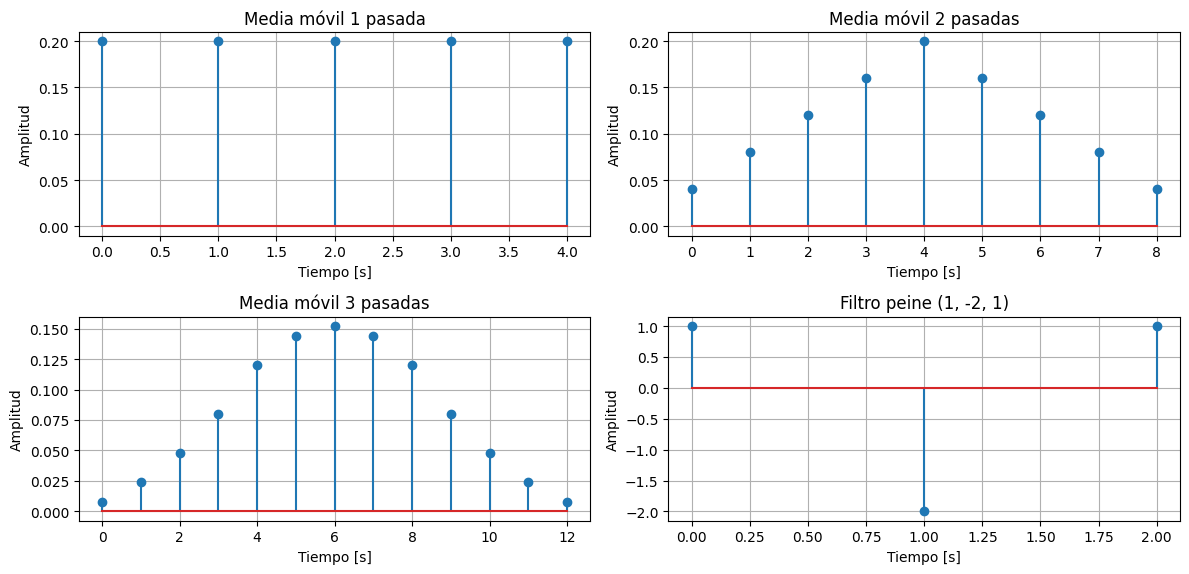

In [5]:
# se generan las respuestas al impulso de cada filtro

h_1p = filtro_media_movil(M=5)
h_2p = np.convolve(h_1p, h_1p)
h_3p = np.convolve(h_2p, h_1p)

h_peine = filtro_peine(b0=1, b1=-2, b2=1)  # un ejemplo de filtro peine

graficar_senales(
    [h_1p, h_2p, h_3p, h_peine],
    subplots=True, stem=True, ncols=2,
    titles=["Media móvil 1 pasada", "Media móvil 2 pasadas", "Media móvil 3 pasadas", "Filtro peine (1, -2, 1)"]
)


### 4. Caracterización en frecuencia de los filtros (módulo y fase)

Para analizar el comportamiento de cada filtro en frecuencia con las funciones armadas, se calcula su respuesta 
en frecuencia H(ω) aplicando el filtro a un impulso y luego calculando la FFT, con la frecuencia normalizada la frecuencia dividida por la frecuencia de muestreo, logrando que de esta manera se pueda caracterizar el filtro sin depender de una `fs`.

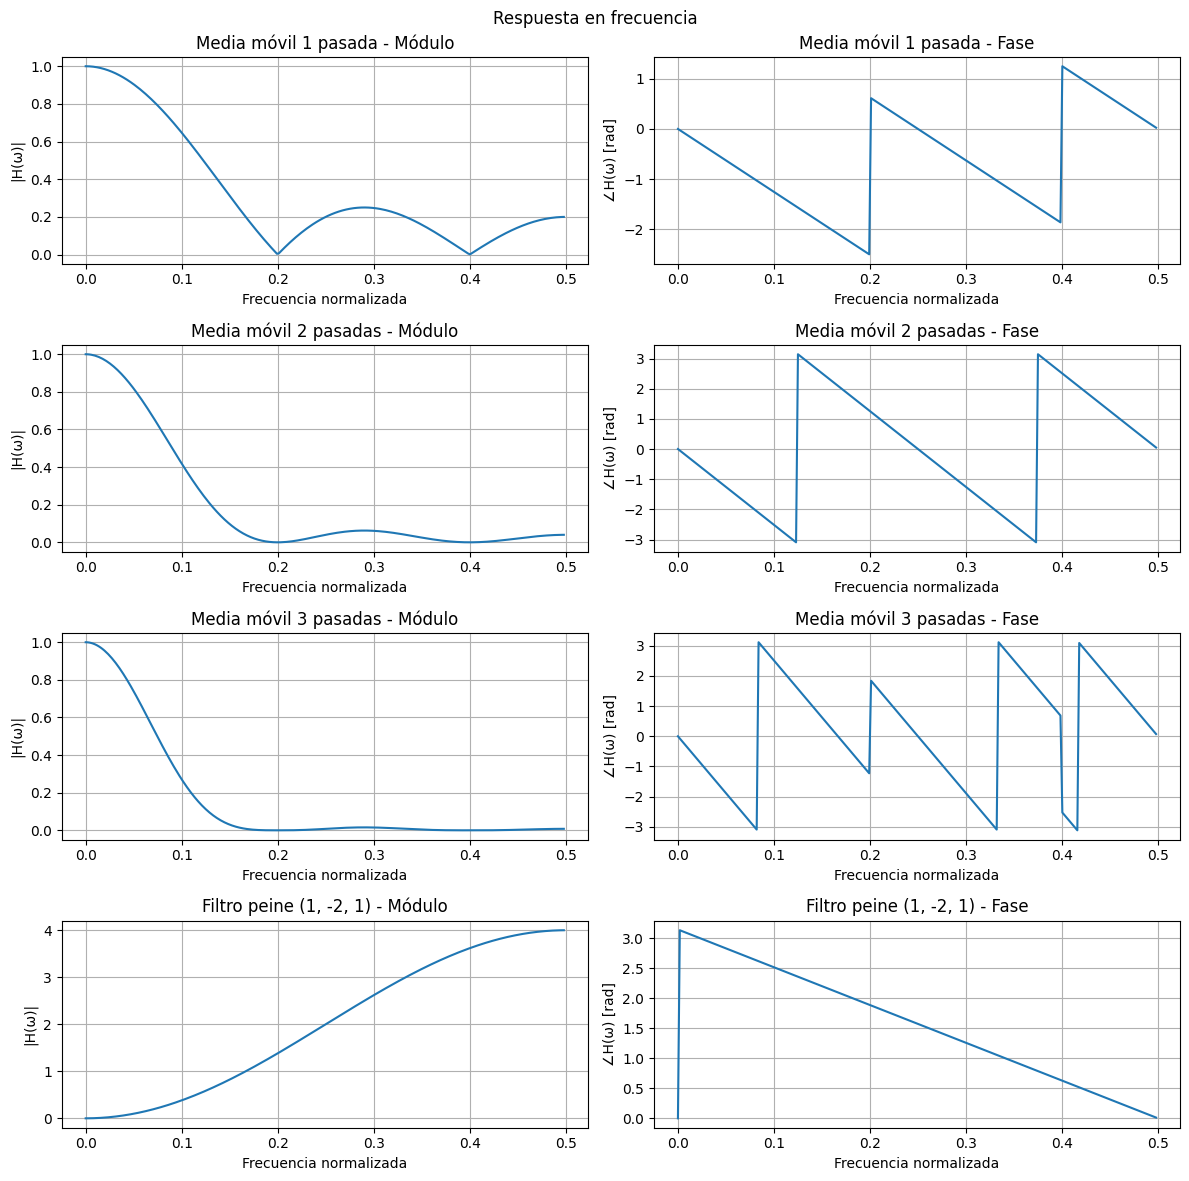

In [6]:
# Creamos un impulso para calcular H(ω) de cada filtro
N = 512
impulso = np.zeros(N)
impulso[0] = 1

y_1p   = filtrar_convolucion(impulso, h_1p)[:N]
y_2p   = filtrar_convolucion(impulso, h_2p)[:N]
y_3p  = filtrar_convolucion(impulso, h_3p)[:N]
y_peine = filtrar_convolucion(impulso, h_peine)[:N]

H_1p, freqs = calcular_H(impulso, y_1p)
H_2p, _ = calcular_H(impulso, y_2p)
H_3p, _ = calcular_H(impulso, y_3p)
H_peine, _ = calcular_H(impulso, y_peine)

graficar_H(
    [H_1p, H_2p, H_3p, H_peine],
    [freqs, freqs, freqs, freqs],
    subplots=True,
    titles=["Media móvil 1 pasada", "Media móvil 2 pasadas", "Media móvil 3 pasadas", "Filtro peine (1, -2, 1)"]
)

### Observación: caracterización en frecuencia de los filtros

#### Media móvil — efecto de las pasadas

La respuesta al impulso de una sola pasada es un pulso rectangular de ancho M. Al aumentar el número de pasadas, la convolución sucesiva de ese pulso consigo mismo produce formas cada vez más suaves: triangular con 2 pasadas, y acampanada (aproximación a una Gaussiana) con 3. Esto se refleja directamente en la respuesta en frecuencia:

- **Módulo**: con más pasadas, el lóbulo principal se mantiene centrado en DC pero los lóbulos secundarios de la sinc se atenúan progresivamente. La respuesta se aproxima a la de un filtro Gaussiano ideal, que no tiene lóbulos laterales. El filtro sigue siendo **pasa-bajos** en todos los casos.
- **Fase**: los tres filtros presentan fase lineal, propiedad característica de todos los filtros FIR simétricos. Esto implica retardo de grupo constante: todas las frecuencias se retrasan la misma cantidad de tiempo, preservando la forma de la señal filtrada.

#### Filtro peine [1, −2, 1]

El comportamiento del filtro peine es opuesto al de la media móvil:

- **Módulo**: la ganancia es cero en DC (frecuencia normalizada = 0) y máxima en la frecuencia de Nyquist (0.5). Esto se verifica directamente: la suma de coeficientes es 1 − 2 + 1 = 0, lo que garantiza atenuación total de la componente continua. Se trata de un filtro **pasa-altos** que resalta los cambios rápidos entre muestras consecutivas.
- **Fase**: también lineal, al ser un FIR simétrico.

#### Comparación entre filtros

| Filtro | Tipo | Ganancia en DC | Lóbulos laterales |
|---|---|---|---|
| Media móvil 1 pasada | Pasa-bajos | 1 | Presentes (sinc) |
| Media móvil 2 pasadas | Pasa-bajos | 1 | Reducidos |
| Media móvil 3 pasadas | Pasa-bajos | 1 | Muy reducidos (Gaussiana) |
| Peine [1,−2,1] | Pasa-altos | 0 | N/A |

### 5. Filtrado de la señal con ruido (MEDIA MOVIL)

Se procede al filtrado de media móvil de los tonos con ruido por medio de la convolucion circular, y tambien por medio de la trasformada, para evaluar las diferencias entre ambos métodos.

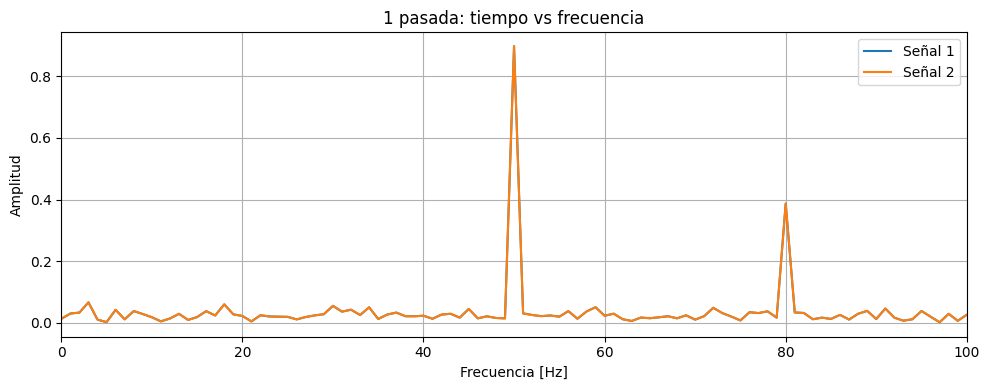

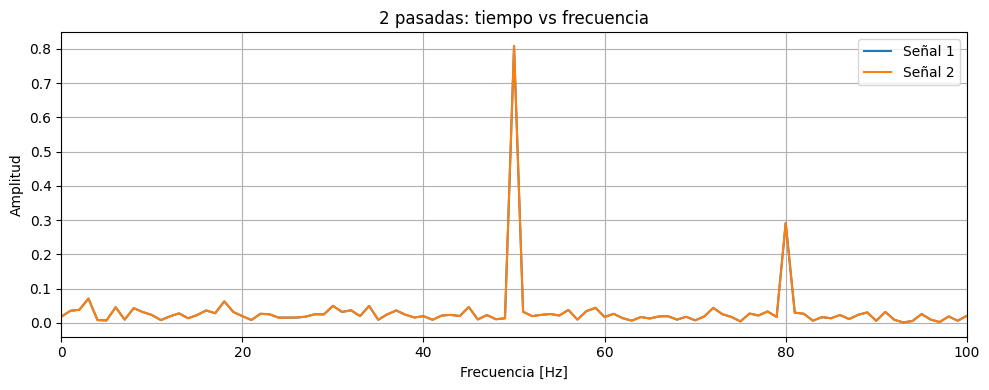

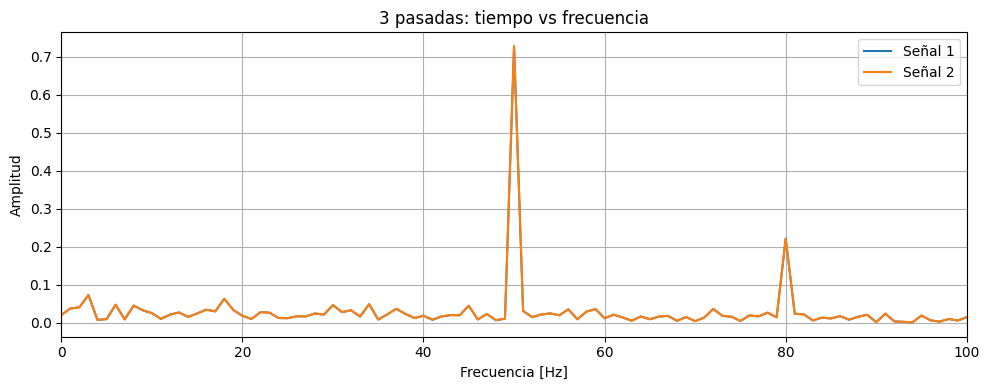

In [7]:
# Se calculan los filtrados
y_1p_tiempo = filtrar_convolucion(tonos_con_ruido, h_1p)[:len(tonos_con_ruido)]
y_2p_tiempo = filtrar_convolucion(tonos_con_ruido, h_2p)[:len(tonos_con_ruido)]
y_3p_tiempo = filtrar_convolucion(tonos_con_ruido, h_3p)[:len(tonos_con_ruido)]

y_1p_freq   = filtrar_frecuencia(tonos_con_ruido, h_1p)[:len(tonos_con_ruido)]
y_2p_freq   = filtrar_frecuencia(tonos_con_ruido, h_2p)[:len(tonos_con_ruido)]
y_3p_freq   = filtrar_frecuencia(tonos_con_ruido, h_3p)[:len(tonos_con_ruido)]

graficar_espectros([y_1p_tiempo, y_1p_freq], fs=fs, titulo="1 pasada: tiempo vs frecuencia", xlim=(0, 100))
graficar_espectros([y_2p_tiempo, y_2p_freq], fs=fs, titulo="2 pasadas: tiempo vs frecuencia", xlim=(0, 100))
graficar_espectros([y_3p_tiempo, y_3p_freq], fs=fs, titulo="3 pasadas: tiempo vs frecuencia", xlim=(0, 100))



Los tres métodos dan exactamente lo mismo, entonces la diferencia no está en el resultado.

In [8]:
# Comparación de tiempos de cómputo (usamos h_3p, el filtro más largo)
N = 1000
t_conv = timeit.timeit(lambda: filtrar_convolucion(tonos_con_ruido, h_3p), number=N) / N * 1000
t_freq = timeit.timeit(lambda: filtrar_frecuencia(tonos_con_ruido, h_3p), number=N) / N * 1000

print(f"Convolución temporal:      {t_conv:.3f} ms")
print(f"Convolución en frecuencia: {t_freq:.3f} ms")
print(f"Razón: {t_conv/t_freq:.1f}x")

Convolución temporal:      0.028 ms
Convolución en frecuencia: 0.036 ms
Razón: 0.8x


### Observación: convolución temporal vs convolución circular en frecuencia

#### Tiempos de cómputo

La convolución en frecuencia resulta más rápida que la convolución temporal, especialmente a medida que el filtro se hace más largo. Esto se debe a que la multiplicación espectral opera sobre vectores de longitud fija (determinada por el zero-padding), mientras que la convolución directa tiene complejidad O(N·M), donde M es la longitud del filtro. Con más pasadas, M crece, y la ventaja del método en frecuencia se vuelve más pronunciada.

Ambos métodos producen resultados equivalentes: el zero-padding aplicado en `filtrar_frecuencia` evita el aliasing circular, haciendo que la convolución circular sea idéntica a la lineal.


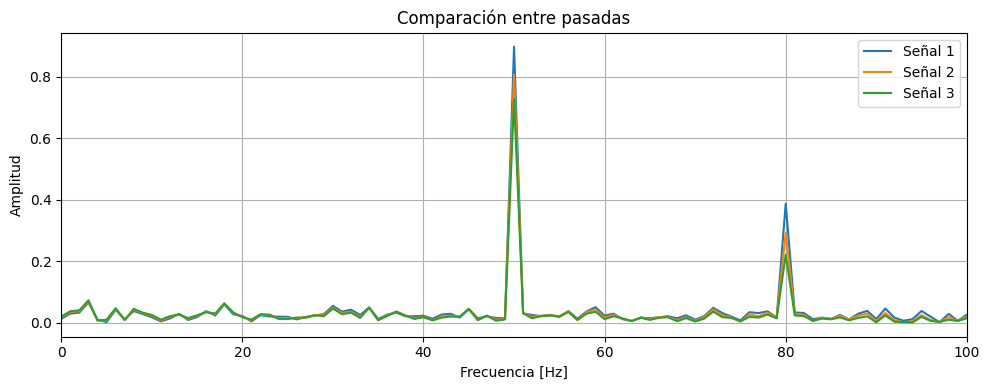

In [9]:
# Comparación entre pasadas: efecto en el espectro
graficar_espectros(
    [y_1p_tiempo, y_2p_tiempo, y_3p_tiempo],
    fs=fs, titulo="Comparación entre pasadas", xlim=(0, 100)
)

#### Efecto de las pasadas sobre el espectro

Al comparar los espectros de las señales filtradas con 1, 2 y 3 pasadas se observa que:
- Con más pasadas, la atenuación de las frecuencias altas es progresivamente mayor.
- Los picos de los tonos (50 Hz y 200 Hz) se preservan en todos los casos, ya que se encuentran dentro de la banda de paso del filtro.
- El piso de ruido se reduce con cada pasada adicional, lo que confirma el mayor efecto suavizante de los filtros con múltiples pasadas.

### Observación: convolución temporal vs circular en frecuencia

**Efecto del filtrado:** el filtro media móvil con M=10 suaviza más la señal que M=3, 
eliminando más ruido pero también "borrando" algo de detalle de la señal original. 
Existe un compromiso entre eliminación de ruido y preservación de la señal.

**Equivalencia de métodos:** las curvas de convolución temporal y convolución circular 
en frecuencia se superponen perfectamente. Esto verifica el **teorema de convolución**: 
convolucionar en el tiempo es equivalente a multiplicar en frecuencia. El zero-padding 
aplicado en `filtrar_frecuencia()` es clave para que la convolución circular sea 
equivalente a la lineal.

### Filtrado de la señal con ruido (PEINE)

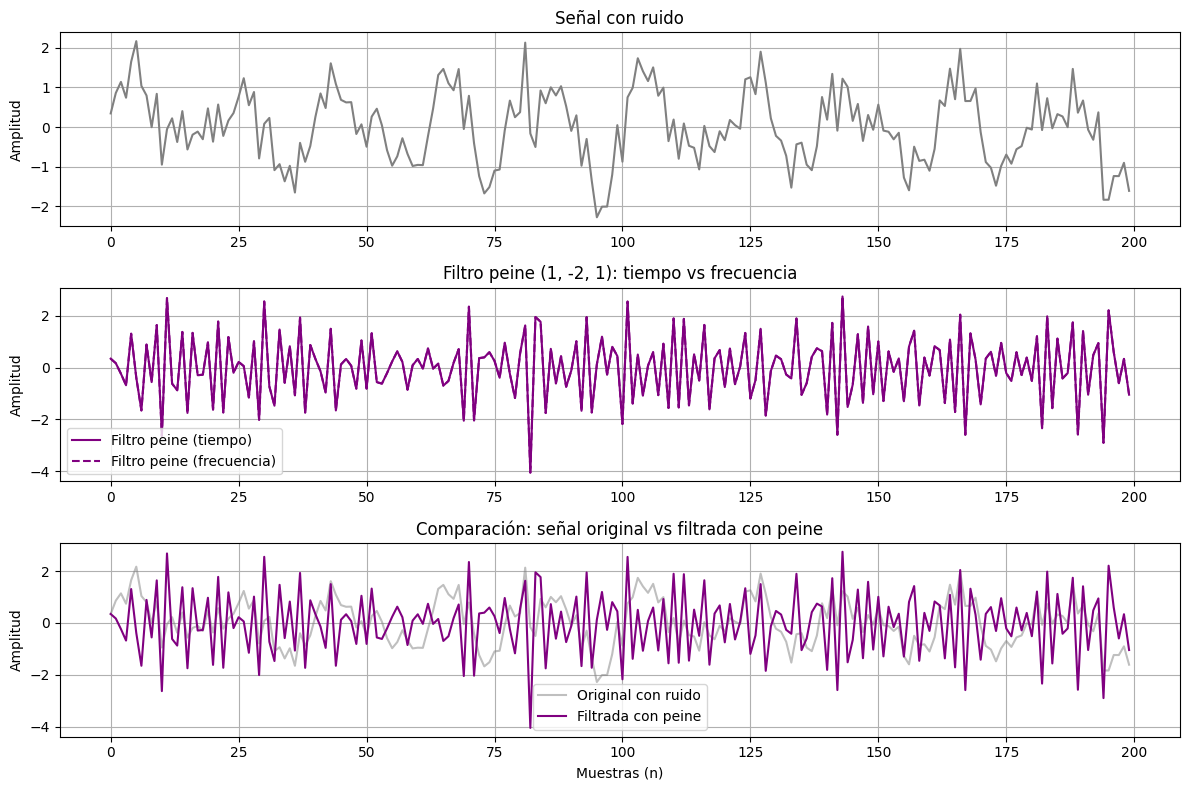

In [10]:
# Aplicamos el filtro peine a la señal con ruido
# Usamos ambos métodos: convolución temporal y convolución circular en frecuencia

y_peine_tiempo = filtrar_convolucion(tonos_con_ruido, h_peine)[:len(tonos_con_ruido)]
y_peine_freq   = filtrar_frecuencia(tonos_con_ruido, h_peine)[:len(tonos_con_ruido)]

# Comparamos temporal: señal original vs filtrada
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(tonos_con_ruido[:200], label="Con ruido", color='gray')
axes[0].set_title("Señal con ruido")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

axes[1].plot(y_peine_tiempo[:200], label="Filtro peine (tiempo)", color='purple')
axes[1].plot(y_peine_freq[:200],   label="Filtro peine (frecuencia)", color='purple', linestyle='--')
axes[1].set_title("Filtro peine (1, -2, 1): tiempo vs frecuencia")
axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(tonos_con_ruido[:200], label="Original con ruido", color='gray', alpha=0.5)
axes[2].plot(y_peine_tiempo[:200], label="Filtrada con peine", color='purple')
axes[2].set_title("Comparación: señal original vs filtrada con peine")
axes[2].set_xlabel("Muestras (n)")
axes[2].set_ylabel("Amplitud")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


### ANÁLISIS ESPECTRAL: EFECTO DEL FILTRO PEINE EN FRECUENCIA


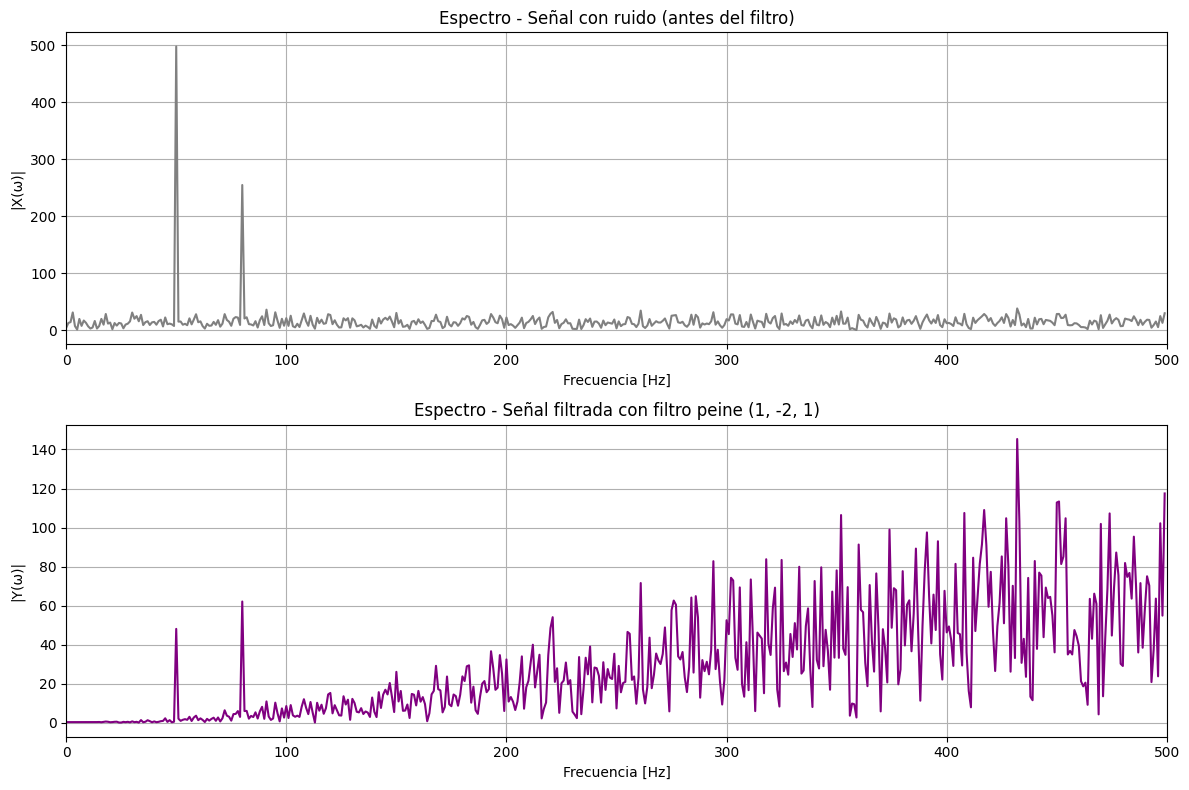

In [11]:
# Graficamos el espectro de la señal antes y después del filtrado
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Espectro original con ruido
X_original = np.fft.fft(tonos_con_ruido)
freqs = np.fft.fftfreq(len(tonos_con_ruido), d=1/fs)
mitad = len(tonos_con_ruido) // 2

axes[0].plot(freqs[:mitad], np.abs(X_original[:mitad]), color='gray')
axes[0].set_title("Espectro - Señal con ruido (antes del filtro)")
axes[0].set_ylabel("|X(ω)|")
axes[0].set_xlabel("Frecuencia [Hz]")
axes[0].grid(True)
axes[0].set_xlim(0, 500)  # Limitamos para ver mejor

# Espectro señal filtrada
Y_peine = np.fft.fft(y_peine_tiempo)
axes[1].plot(freqs[:mitad], np.abs(Y_peine[:mitad]), color='purple')
axes[1].set_title("Espectro - Señal filtrada con filtro peine (1, -2, 1)")
axes[1].set_ylabel("|Y(ω)|")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].grid(True)
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

### Observación: convolución temporal vs circular en frecuencia

**Efecto del filtrado:** el filtro peine h=[1,−2,1] modifica la señal de manera muy distinta al filtro media móvil. En lugar de suavizarla, resalta las variaciones rápidas y los cambios bruscos entre muestras consecutivas. Como consecuencia, la salida presenta oscilaciones más pronunciadas y una reducción importante de las componentes de baja frecuencia. En el espectro se aprecia que las frecuencias bajas son fuertemente atenuadas, mientras que las componentes más altas permanecen más visibles, evidenciando el carácter pasa-altos del filtro.

**Comparación entre métodos:** los resultados obtenidos mediante convolución directa y mediante procesamiento en frecuencia coinciden prácticamente muestra a muestra, lo que confirma la equivalencia entre ambos enfoques. El uso de zero-padding en la implementación con FFT permite evitar efectos de convolución circular no deseados y reproducir correctamente la convolución lineal del filtro FIR.

### Filtrado de la señal con ruido (FIR)

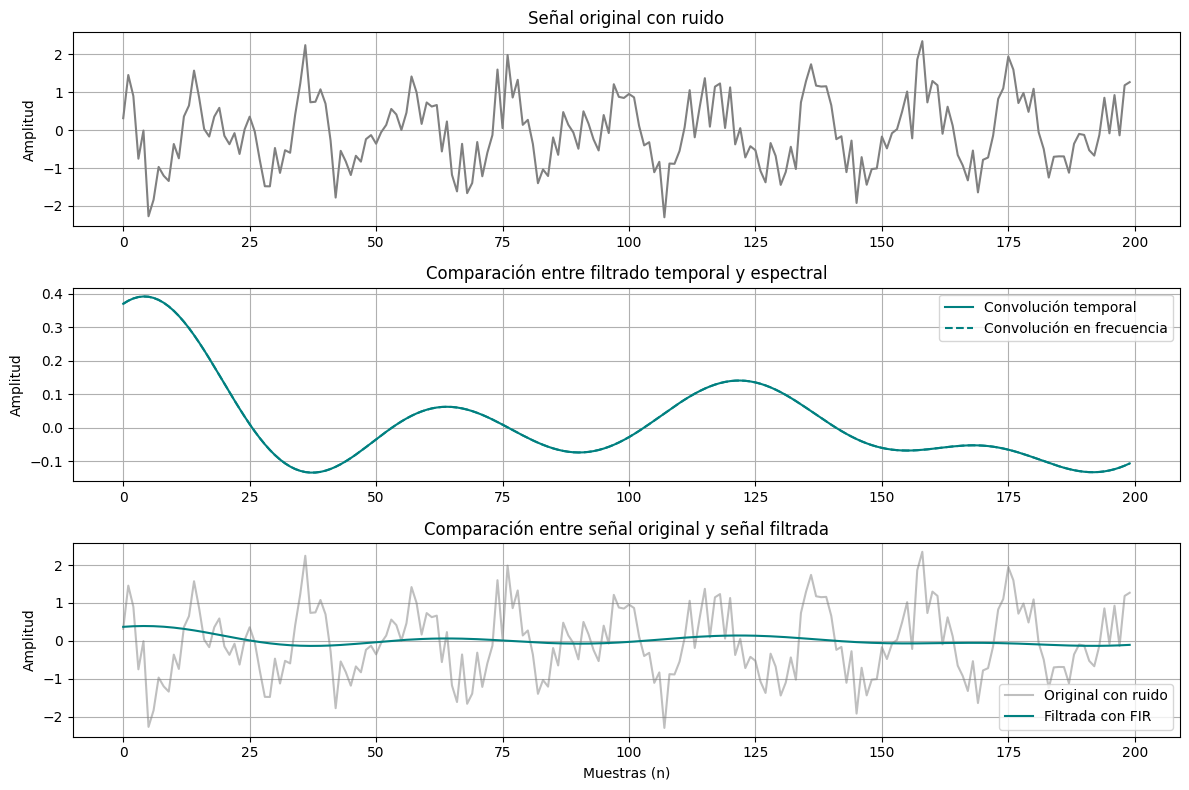

In [12]:
# Aplicamos el filtro FIR a la señal con ruido
# Comparación entre convolución temporal y filtrado en frecuencia

fir = cargar_filtro_fir("fir_hamming_1000Hz.npy")

# Filtrado
y_fir_tiempo = filtrar_convolucion(tonos_con_ruido, fir)
y_fir_freq   = filtrar_frecuencia(tonos_con_ruido, fir)

# Calculamos retardo aproximado del FIR
delay = (len(fir) - 1) // 2

# Recortamos para visualizar después del transitorio
inicio = delay
fin = delay + 200

# Graficamos
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Señal original
axes[0].plot(
    tonos_con_ruido[inicio:fin],
    color="gray"
)

axes[0].set_title("Señal original con ruido")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True)

# Comparación de implementaciones
axes[1].plot(
    y_fir_tiempo[inicio:fin],
    label="Convolución temporal",
    color="teal"
)

axes[1].plot(
    y_fir_freq[inicio:fin],
    "--",
    label="Convolución en frecuencia",
    color="teal"
)

axes[1].set_title(
    "Comparación entre filtrado temporal y espectral"
)

axes[1].set_ylabel("Amplitud")
axes[1].legend()
axes[1].grid(True)

# Señal original vs filtrada
axes[2].plot(
    tonos_con_ruido[inicio:fin],
    label="Original con ruido",
    color="gray",
    alpha=0.5
)

axes[2].plot(
    y_fir_tiempo[inicio:fin],
    label="Filtrada con FIR",
    color="teal"
)

axes[2].set_title(
    "Comparación entre señal original y señal filtrada"
)

axes[2].set_xlabel("Muestras (n)")
axes[2].set_ylabel("Amplitud")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

El filtro FIR utilizado posee 1457 coeficientes, por lo que introduce un retardo aproximado de 728 muestras. Para evitar interpretar el transitorio inicial como una atenuación excesiva, la comparación temporal se realizó desplazando la visualización hasta después del retardo de grupo. Se observa además que el filtrado por convolución temporal y por multiplicación en frecuencia producen resultados equivalentes.

### 6. IDENTIFICACIÓN DE SISTEMA

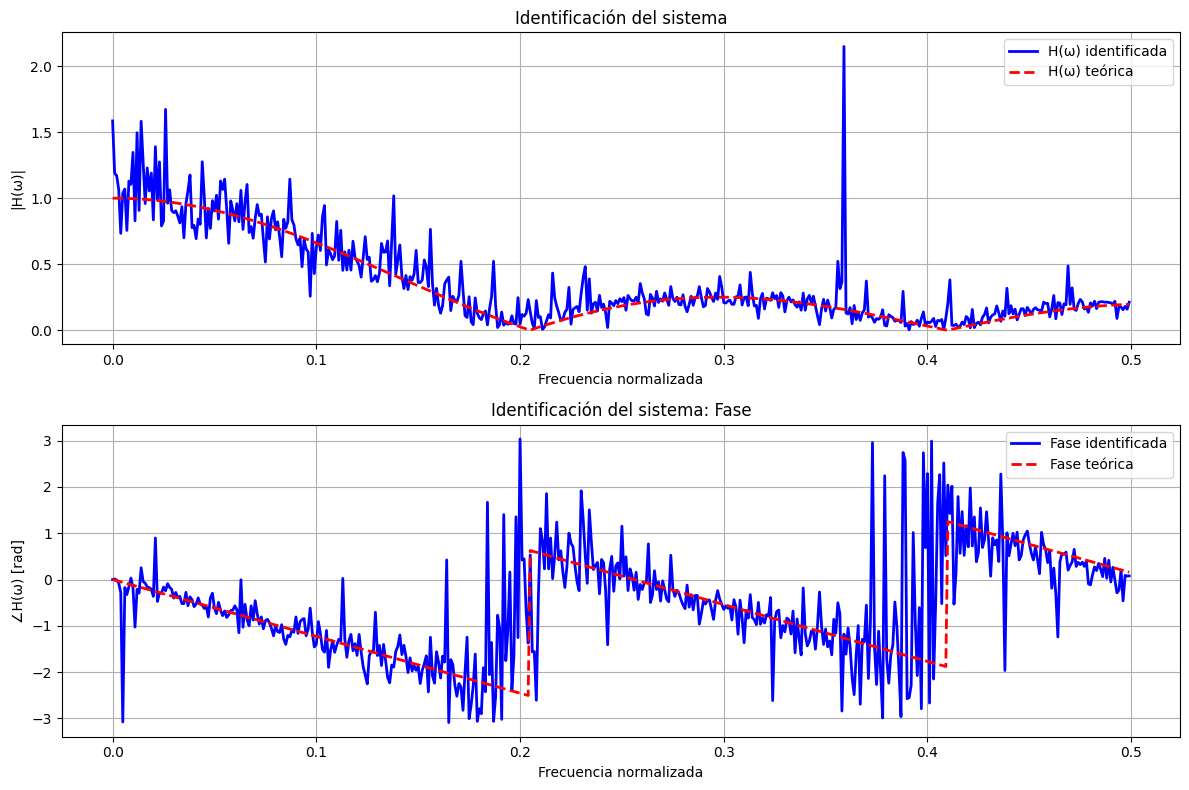

In [13]:
# Usamos el sistema media móvil M=5 como sistema a identificar
sistema_a_identificar = filtro_media_movil(5)

# Usamos la señal con ruido 
entrada = tonos_con_ruido

# Calculamos la salida del sistema
salida = filtrar_convolucion(entrada, sistema_a_identificar)[:len(entrada)]

# Identificamos H(ω)
H_identificada, freqs_id = calcular_H(entrada, salida)

# Calculamos H(ω) teórica (comparación)
impulso = np.zeros(1024)
impulso[0] = 1
salida_teorica = filtrar_convolucion(impulso, sistema_a_identificar)[:1024]
H_teorica, _ = calcular_H(impulso, salida_teorica)

# Graficamos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
mitad = len(freqs_id) // 2

ax1.plot(freqs_id[:mitad], np.abs(H_identificada[:mitad]), 'b-', label="H(ω) identificada", linewidth=2)
ax1.plot(freqs_id[:mitad], np.abs(H_teorica[:mitad]), 'r--', label="H(ω) teórica", linewidth=2)
ax1.set_title("Identificación del sistema")
ax1.set_xlabel("Frecuencia normalizada")
ax1.set_ylabel("|H(ω)|")
ax1.legend()
ax1.grid(True)

ax2.plot(freqs_id[:mitad], np.angle(H_identificada[:mitad]), 'b-', label="Fase identificada", linewidth=2)
ax2.plot(freqs_id[:mitad], np.angle(H_teorica[:mitad]), 'r--', label="Fase teórica", linewidth=2)
ax2.set_title("Identificación del sistema: Fase")
ax2.set_xlabel("Frecuencia normalizada")
ax2.set_ylabel("∠H(ω) [rad]")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()